[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Sk-2103/AI4Sustainability-Labs/blob/main/labs/lab03_ann_biodiversity/lab03_ann_biodiversity.ipynb)  
**AI for Sustainability** · University of Wisconsin–Madison · Labs by Saurabh Kaushik · Course instructor: Dr. Beth Tellman  
*Make a copy (File → Save a copy in Drive) before you start. Part of the [AI for Sustainability lab series](https://github.com/Sk-2103/AI4Sustainability-Labs).*

# 🌿 AI for Sustainability — Lab 3: Artificial Neural Networks
## Biodiversity Conservation: Plant Species Classification with ANNs

---

**Course:** AI for Sustainability  
**Lab:** 3 — Artificial Neural Networks (ANN)  
**Dataset:** UCI Iris Dataset (proxy for botanical species classification)  


---

### 🎯 Learning Objectives
By the end of this lab, you will be able to:
1. Understand the **biological inspiration** behind artificial neurons
2. Build and train an ANN **from scratch** using NumPy
3. Build and train an ANN using **PyTorch**
4. Visualize **decision boundaries**, **loss curves**, and **weight activations**
5. Apply ANNs to a real **biodiversity / species classification** problem
6. Critically evaluate model performance using appropriate metrics

---

### 🌍 Why This Matters for Sustainability
Rapid, automated species identification is critical for:
- **Biodiversity monitoring** in the field (camera traps, drones)
- **Invasive species detection** to protect ecosystems
- **Climate change impact** assessments on plant communities
- **Conservation prioritization** with limited ranger resources

ANNs power the computer vision models used in iNaturalist, PlantNet, and eBird — tools that have crowdsourced **100+ million biodiversity observations** globally.


## 📦 Section 0: Environment Setup

In [ ]:
# Install / import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("✅ All libraries loaded successfully!")
print(f"   PyTorch version : {torch.__version__}")
print(f"   NumPy   version : {np.__version__}")


✅ All libraries loaded successfully!
   PyTorch version : 2.10.0+cpu
   NumPy   version : 2.0.2


## 🌸 Section 1: The Iris Dataset — A Botanical Biodiversity Problem

The **Iris dataset** (Fisher, 1936) contains morphological measurements of three *Iris* species collected from the Gaspé Peninsula, Canada.

| Species | Common Name | Conservation Status |
|---|---|---|
| *Iris setosa* | Bristle-pointed iris | Least concern |
| *Iris versicolor* | Blue flag iris | Least concern |
| *Iris virginica* | Virginia iris | Least concern |

**Features measured (in cm):**
- Sepal length, Sepal width
- Petal length, Petal width

This is analogous to a field botanist using leaf/flower morphometrics to classify plant species — a core task in **vegetation biodiversity surveys**.


In [ ]:
# ── Load the Iris dataset ──
iris = load_iris()
X = iris.data          # shape: (150, 4)
y = iris.target        # 0=setosa, 1=versicolor, 2=virginica
feature_names = iris.feature_names
class_names   = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df['species'] = [class_names[i] for i in y]

print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df['species'].value_counts())
print("\nFirst 5 rows:")
df.head()


Dataset shape: (150, 5)

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


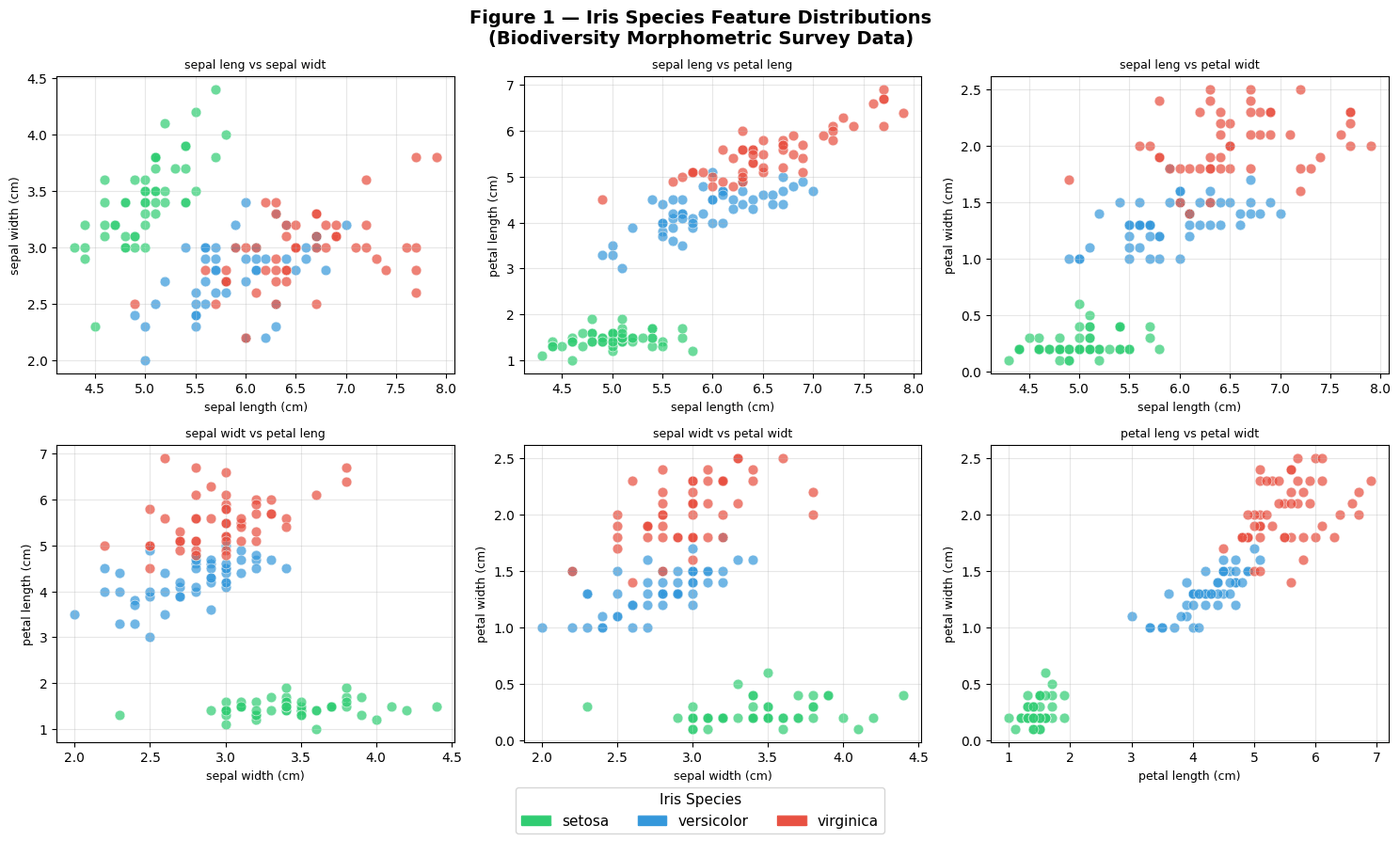

💡 Notice how Iris setosa is easily separable but versicolor/virginica overlap!


In [ ]:
# ── Figure 1: Species photos placeholder + feature distributions ──
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Figure 1 — Iris Species Feature Distributions\n"
             "(Biodiversity Morphometric Survey Data)", fontsize=14, fontweight='bold')

colors = ['#2ecc71', '#3498db', '#e74c3c']
species_list = class_names

# Plot pairwise feature distributions
plot_pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
for ax, (i, j) in zip(axes.flat, plot_pairs):
    for k, (sp, col) in enumerate(zip(species_list, colors)):
        mask = y == k
        ax.scatter(X[mask, i], X[mask, j], c=col, label=sp,
                   alpha=0.7, edgecolors='white', linewidth=0.5, s=60)
    ax.set_xlabel(feature_names[i], fontsize=9)
    ax.set_ylabel(feature_names[j], fontsize=9)
    ax.set_title(f'{feature_names[i][:10]} vs {feature_names[j][:10]}', fontsize=9)
    ax.grid(True, alpha=0.3)

handles = [mpatches.Patch(color=c, label=s) for c, s in zip(colors, species_list)]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=11,
           title='Iris Species', title_fontsize=11)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('fig1_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Notice how Iris setosa is easily separable but versicolor/virginica overlap!")


## The whole idea of deep learning is to have computers artificially mimic biological natural intelligence.

## 🧠 Section 2: From Biological Neurons to Artificial Neurons

### The Inspiration from Nature

The **biological neuron** and the **artificial neuron (perceptron)** share a fundamental logic:

| Biological Component | Artificial Equivalent |
|---|---|
| Dendrites | Input features (x₁, x₂, ...) |
| Synaptic weights | Learned weights (w₁, w₂, ...) |
| Cell body (soma) | Weighted sum + bias |
| Axon hillock | Activation function threshold |
| Axon output | Neuron output ŷ |

**Mathematical formulation of a single neuron:**

$$z = \sum_{i=1}^{n} w_i x_i + b$$

$$\hat{y} = \sigma(z)$$

where σ is the **activation function**.


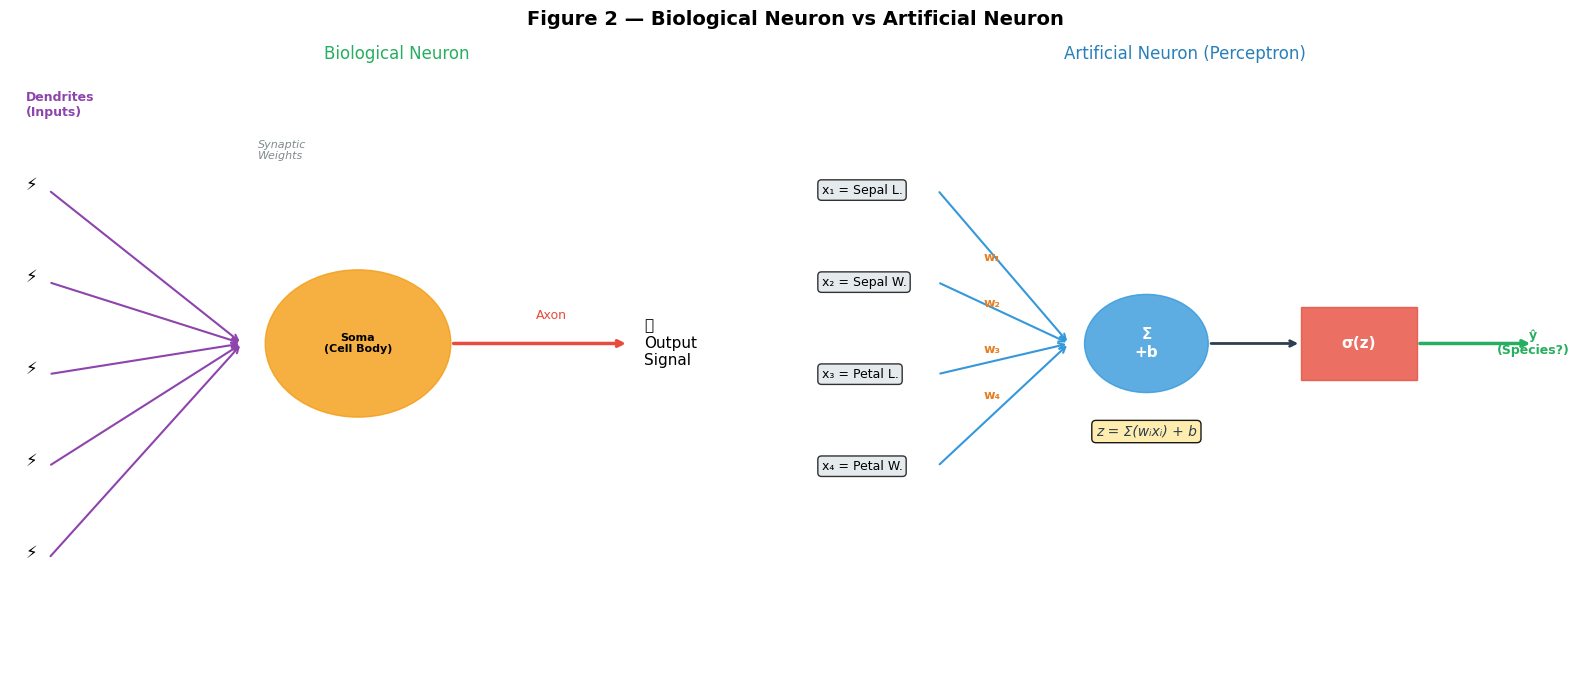

In [ ]:
# ── Figure 2: Biological vs Artificial Neuron Diagram ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Figure 2 — Biological Neuron vs Artificial Neuron",
             fontsize=14, fontweight='bold')

# ── Left: Biological neuron sketch ──
ax1.set_xlim(0, 10); ax1.set_ylim(0, 10); ax1.axis('off')
ax1.set_title("Biological Neuron", fontsize=12, color='#27ae60')

# Dendrites
dendrite_starts = [(0.5,8),(0.5,6.5),(0.5,5),(0.5,3.5),(0.5,2)]
for (dx,dy) in dendrite_starts:
    ax1.annotate('', xy=(3, 5.5), xytext=(dx, dy),
                arrowprops=dict(arrowstyle='->', color='#8e44ad', lw=1.5))
    ax1.text(dx-0.3, dy, '⚡', fontsize=12)

# Cell body
circle = plt.Circle((4.5, 5.5), 1.2, color='#f39c12', alpha=0.8, zorder=3)
ax1.add_patch(circle)
ax1.text(4.5, 5.5, 'Soma\n(Cell Body)', ha='center', va='center', fontsize=8, fontweight='bold')

# Axon
ax1.annotate('', xy=(8, 5.5), xytext=(5.7, 5.5),
            arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=2.5))
ax1.text(6.8, 5.9, 'Axon', fontsize=9, color='#e74c3c')
ax1.text(8.2, 5.5, '🔥\nOutput\nSignal', fontsize=11, va='center')

ax1.text(0.2, 9.2, 'Dendrites\n(Inputs)', fontsize=9, color='#8e44ad', fontweight='bold')
ax1.text(3.2, 8.5, 'Synaptic\nWeights', fontsize=8, color='#7f8c8d', style='italic')

# ── Right: Artificial neuron ──
ax2.set_xlim(0, 10); ax2.set_ylim(0, 10); ax2.axis('off')
ax2.set_title("Artificial Neuron (Perceptron)", fontsize=12, color='#2980b9')

inputs = [('x₁ = Sepal L.', 8.0), ('x₂ = Sepal W.', 6.5),
          ('x₃ = Petal L.', 5.0), ('x₄ = Petal W.', 3.5)]
weights = ['w₁', 'w₂', 'w₃', 'w₄']

for (label, y_pos), w in zip(inputs, weights):
    ax2.text(0.3, y_pos, label, fontsize=9, va='center',
             bbox=dict(boxstyle='round', facecolor='#dfe6e9', alpha=0.8))
    ax2.annotate('', xy=(3.5, 5.5), xytext=(1.8, y_pos),
                arrowprops=dict(arrowstyle='->', color='#3498db', lw=1.5))
    ax2.text(2.4, (y_pos+5.5)/2 + 0.1, w, fontsize=9,
             color='#e67e22', fontweight='bold')

# Summation node
circ2 = plt.Circle((4.5, 5.5), 0.8, color='#3498db', alpha=0.8, zorder=3)
ax2.add_patch(circ2)
ax2.text(4.5, 5.5, 'Σ\n+b', ha='center', va='center', fontsize=11,
         color='white', fontweight='bold')

# Activation
ax2.annotate('', xy=(6.5, 5.5), xytext=(5.3, 5.5),
            arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=2))
act_box = plt.Rectangle((6.5, 4.9), 1.5, 1.2, color='#e74c3c', alpha=0.8, zorder=3)
ax2.add_patch(act_box)
ax2.text(7.25, 5.5, 'σ(z)', ha='center', va='center', fontsize=11,
         color='white', fontweight='bold')

# Output
ax2.annotate('', xy=(9.5, 5.5), xytext=(8.0, 5.5),
            arrowprops=dict(arrowstyle='->', color='#27ae60', lw=2.5))
ax2.text(9.5, 5.5, 'ŷ\n(Species?)', ha='center', va='center', fontsize=9,
         color='#27ae60', fontweight='bold')
ax2.text(4.5, 4.0, 'z = Σ(wᵢxᵢ) + b', ha='center', fontsize=10,
         style='italic', color='#2c3e50',
         bbox=dict(boxstyle='round', facecolor='#ffeaa7', alpha=0.9))

plt.tight_layout()
plt.savefig('fig2_neuron_diagram.png', dpi=150, bbox_inches='tight')
plt.show()


## Simple Illustration of the Perceptron Model

<div style="text-align:center">
    <img src="https://drive.google.com/thumbnail?id=1uV3dBBvNSNBJuDKDpKAe86pvg8TkyA2B&sz=w700" width="700"/>
    <p style="font-style:italic; color:gray; font-size:12px">
      
    
</div>

## ⚡ Section 3: Activation Functions — The Neurons' "Decision Rule"

Activation functions introduce **non-linearity**, allowing ANNs to learn complex patterns (e.g., distinguishing overlapping species).

| Function | Formula | Use Case |
|---|---|---|
| Sigmoid | σ(z) = 1/(1+e⁻ᶻ) | Binary classification output |
| ReLU | max(0, z) | Hidden layers (most common) |
| Tanh | (eᶻ - e⁻ᶻ)/(eᶻ + e⁻ᶻ) | Hidden layers |
| Softmax | eᶻᵢ/Σeᶻⱼ | Multi-class output |


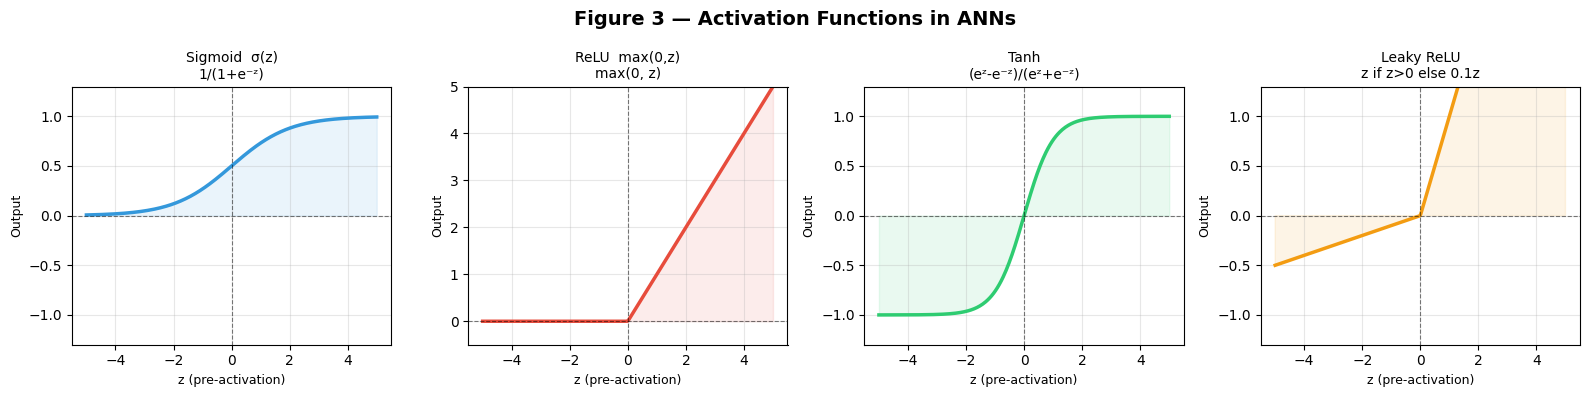

💡 ReLU is the most popular for hidden layers; Softmax is used for multi-class outputs!


In [ ]:
# ── Figure 3: Activation Functions ──
z = np.linspace(-5, 5, 300)

sigmoid = 1 / (1 + np.exp(-z))
relu    = np.maximum(0, z)
tanh    = np.tanh(z)
leaky   = np.where(z > 0, z, 0.1 * z)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Figure 3 — Activation Functions in ANNs",
             fontsize=14, fontweight='bold')

funcs   = [sigmoid, relu, tanh, leaky]
names   = ['Sigmoid  σ(z)', 'ReLU  max(0,z)', 'Tanh', 'Leaky ReLU']
colors  = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
formulas= ['1/(1+e⁻ᶻ)', 'max(0, z)', '(eᶻ-e⁻ᶻ)/(eᶻ+e⁻ᶻ)', 'z if z>0 else 0.1z']

for ax, f, name, col, form in zip(axes, funcs, names, colors, formulas):
    ax.plot(z, f, color=col, lw=2.5)
    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.axvline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_title(f'{name}\n{form}', fontsize=10)
    ax.set_xlabel('z (pre-activation)', fontsize=9)
    ax.set_ylabel('Output', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-1.3, 1.3) if name != 'ReLU  max(0,z)' else ax.set_ylim(-0.5, 5)
    ax.fill_between(z, f, alpha=0.1, color=col)

plt.tight_layout()
plt.savefig('fig3_activations.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 ReLU is the most popular for hidden layers; Softmax is used for multi-class outputs!")


### more about activation functions https://en.wikipedia.org/wiki/Activation_function

## 🏗️ Section 4: ANN Architecture — The Multi-Layer Perceptron (MLP)

A **Multi-Layer Perceptron** stacks multiple layers:

```
Input Layer  →  Hidden Layer(s)  →  Output Layer
[4 features]    [neurons + ReLU]    [3 classes: softmax]
```

**Key hyperparameters:**
- Number of hidden layers (depth)
- Number of neurons per layer (width)
- Activation function
- Learning rate, batch size, epochs


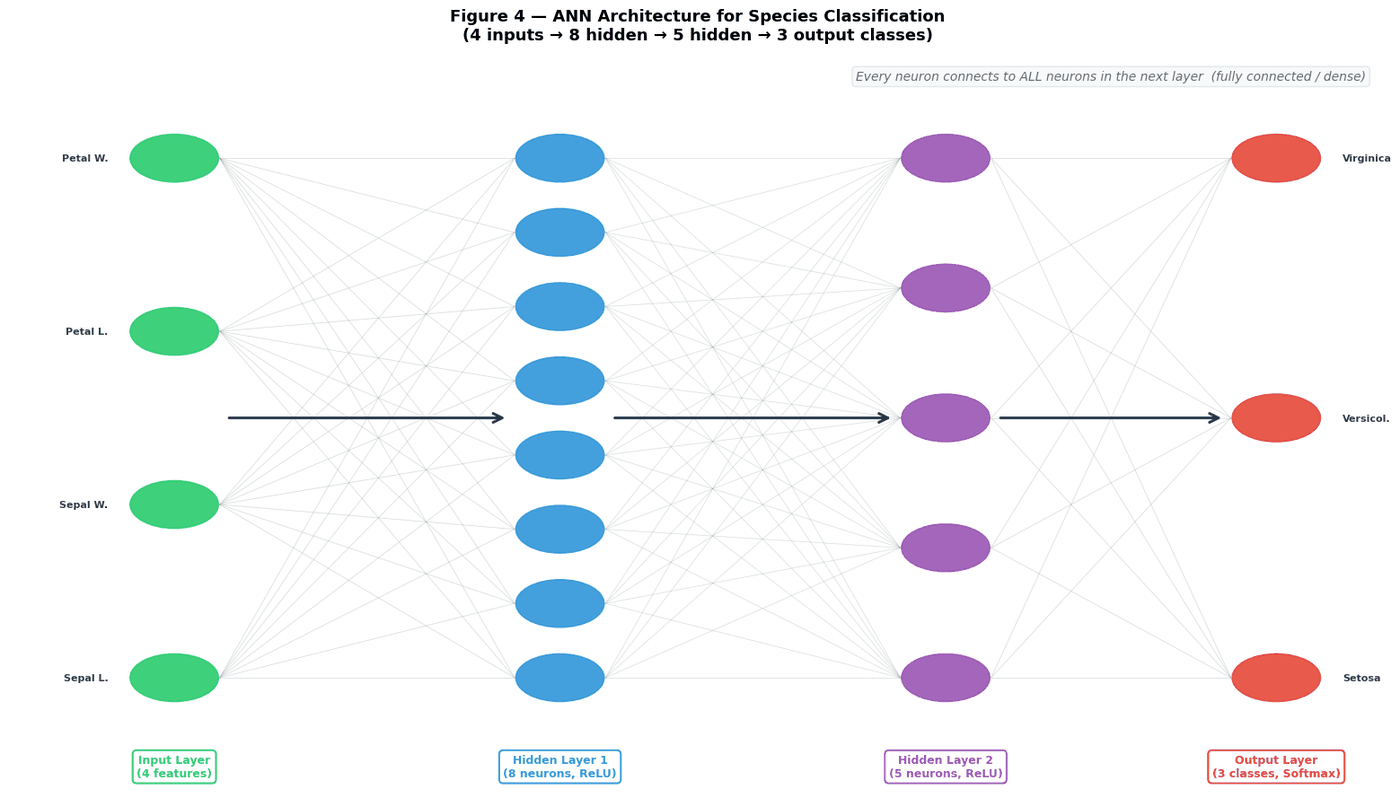

In [ ]:
# ── Figure 4: MLP Architecture Diagram (Fully Connected) ──
fig, ax = plt.subplots(figsize=(16, 9))
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
ax.set_title("Figure 4 \u2014 ANN Architecture for Species Classification\n"
             "(4 inputs \u2192 8 hidden \u2192 5 hidden \u2192 3 output classes)",
             fontsize=13, fontweight='bold')

layer_configs = [
    (1.2, 4, ['Sepal L.','Sepal W.','Petal L.','Petal W.'], '#2ecc71', "Input Layer\n(4 features)"),
    (4.0, 8, ['']*8,                                         '#3498db', "Hidden Layer 1\n(8 neurons, ReLU)"),
    (6.8, 5, ['']*5,                                         '#9b59b6', "Hidden Layer 2\n(5 neurons, ReLU)"),
    (9.2, 3, ['Setosa','Versicol.','Virginica'],              '#e74c3c', "Output Layer\n(3 classes, Softmax)"),
]

# ── 1. Collect node positions ──
node_positions = []
for (x, n, labels, col, title) in layer_configs:
    ys = np.linspace(1.5, 8.5, n)
    node_positions.append([(x, float(y)) for y in ys])

# ── 2. Draw ALL connections first (zorder=1, behind nodes) ──
for l_idx in range(len(node_positions) - 1):
    src = node_positions[l_idx]
    dst = node_positions[l_idx + 1]
    alpha = max(0.04, min(0.28, 10.0 / (len(src) * len(dst))))
    for s in src:
        for d in dst:
            ax.plot([s[0]+0.33, d[0]-0.33], [s[1], d[1]],
                    color='#7f8c8d', lw=0.6, alpha=alpha, zorder=1)

# ── 3. Draw nodes on top (zorder=3) ──
for (x, n, labels, col, title) in layer_configs:
    ys = np.linspace(1.5, 8.5, n)
    for y, lbl in zip(ys, labels):
        circle = plt.Circle((x, float(y)), 0.32, color=col, alpha=0.92,
                             zorder=3, linewidth=1.2, edgecolor='white')
        ax.add_patch(circle)
        if lbl:
            ha     = 'right' if x < 3 else 'left'
            offset = -0.48   if x < 3 else 0.48
            ax.text(x + offset, float(y), lbl, ha=ha, va='center',
                    fontsize=8, color='#2c3e50', fontweight='bold')
    ax.text(x, 0.3, title, ha='center', va='center', fontsize=9,
            fontweight='bold', color=col,
            bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                      edgecolor=col, linewidth=1.5, alpha=0.95))

# ── 4. Forward-pass arrows between layers ──
for i in range(len(node_positions) - 1):
    x_src = node_positions[i][0][0]
    x_dst = node_positions[i+1][0][0]
    ax.annotate('', xy=(x_dst - 0.38, 5.0), xytext=(x_src + 0.38, 5.0),
                arrowprops=dict(arrowstyle='->', color='#2c3e50',
                                lw=2.2, mutation_scale=18), zorder=5)

# ── 5. Annotation ──
ax.text(8, 9.55,
        "Every neuron connects to ALL neurons in the next layer  (fully connected / dense)",
        ha='center', fontsize=10, style='italic', color='#636e72',
        bbox=dict(boxstyle='round', facecolor='#f8f9fa', edgecolor='#dfe6e9', alpha=0.9))

plt.tight_layout()
plt.savefig('fig4_architecture.png', dpi=150, bbox_inches='tight')
plt.show()


## 🔬 Section 5: Build an ANN from Scratch (Pytorch)

Before using high-level frameworks, let's build a **2-layer ANN from scratch** to deeply understand what's happening under the hood.

### Forward Pass
$$z^{[1]} = W^{[1]}X + b^{[1]}, \quad A^{[1]} = \text{ReLU}(z^{[1]})$$
$$z^{[2]} = W^{[2]}A^{[1]} + b^{[2]}, \quad \hat{y} = \text{Softmax}(z^{[2]})$$

### Loss: Categorical Cross-Entropy
$$\mathcal{L} = -\frac{1}{m}\sum_{i=1}^{m}\sum_{k=1}^{K} y_{ik} \log(\hat{y}_{ik})$$

### Backpropagation (Gradient Descent)
$$W := W - \alpha \frac{\partial \mathcal{L}}{\partial W}$$


In [ ]:
# ── Data Preparation ──
iris = load_iris()
X_all, y_all = iris.data.astype(np.float32), iris.target

# Normalize
scaler = StandardScaler()
X_all = scaler.fit_transform(X_all)

# One-hot encode
def one_hot(y, n_classes):
    ohe = np.zeros((len(y), n_classes))
    ohe[np.arange(len(y)), y] = 1
    return ohe

X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.2,
                                            random_state=42, stratify=y_all)
Y_tr = one_hot(y_tr, 3)
Y_te = one_hot(y_te, 3)

print(f"Training set : {X_tr.shape[0]} samples")
print(f"Test set     : {X_te.shape[0]} samples")
print(f"X shape: {X_tr.shape}  |  Y shape: {Y_tr.shape}")


Training set : 120 samples
Test set     : 30 samples
X shape: (120, 4)  |  Y shape: (120, 3)


## 🔥 Section 6: ANN with PyTorch — Production-Ready Framework

PyTorch is the framework behind most modern AI biodiversity tools (e.g., iNaturalist's computer vision models). Let's rebuild our species classifier using PyTorch.


In [ ]:
# ── PyTorch Model Definition ──
class SpeciesANN(nn.Module):
    def __init__(self, input_dim=4, hidden1=16, hidden2=8, output_dim=3, dropout_p=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(dropout_p),

            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(dropout_p),

            nn.Linear(hidden2, output_dim)
            # No softmax here — nn.CrossEntropyLoss includes LogSoftmax
        )

    def forward(self, x):
        return self.net(x)

# Instantiate and print
model_pt = SpeciesANN()
print(model_pt)
total_params = sum(p.numel() for p in model_pt.parameters())
print(f"\nTotal trainable parameters: {total_params}")

## The selection of loss function depends

SpeciesANN(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=8, out_features=3, bias=True)
  )
)

Total trainable parameters: 291


In [ ]:
# ── Prepare PyTorch DataLoaders ──
X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr, dtype=torch.long)
X_te_t = torch.tensor(X_te, dtype=torch.float32)
y_te_t = torch.tensor(y_te, dtype=torch.long)

train_ds = TensorDataset(X_tr_t, y_tr_t)
train_dl = DataLoader(train_ds, batch_size=16, shuffle=True)

# ── Training loop ──
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_pt.parameters(), lr=0.005, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.7)

EPOCHS = 200
train_losses, train_accs, val_losses, val_accs = [], [], [], []

for epoch in range(EPOCHS):
    # --- Training ---
    model_pt.train()
    batch_losses = []
    for xb, yb in train_dl:
        optimizer.zero_grad()
        logits = model_pt(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    scheduler.step()

    # --- Validation ---
    model_pt.eval()
    with torch.no_grad():
        tr_logits = model_pt(X_tr_t)
        val_logits = model_pt(X_te_t)
        tr_loss  = criterion(tr_logits, y_tr_t).item()
        val_loss = criterion(val_logits, y_te_t).item()
        tr_acc   = (tr_logits.argmax(1) == y_tr_t).float().mean().item()
        val_acc  = (val_logits.argmax(1) == y_te_t).float().mean().item()

    train_losses.append(tr_loss); val_losses.append(val_loss)
    train_accs.append(tr_acc);   val_accs.append(val_acc)

    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1:3d} | Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

print("\n✅ PyTorch Training Complete!")

Epoch  50 | Train Loss: 0.0727 Acc: 0.9833 | Val Loss: 0.0878 Acc: 1.0000
Epoch 100 | Train Loss: 0.0773 Acc: 0.9750 | Val Loss: 0.1012 Acc: 1.0000
Epoch 150 | Train Loss: 0.0759 Acc: 0.9917 | Val Loss: 0.1011 Acc: 1.0000
Epoch 200 | Train Loss: 0.0667 Acc: 0.9750 | Val Loss: 0.0911 Acc: 1.0000

✅ PyTorch Training Complete!


### Selection of loss function depends on the input data and task, please see guide to learn more https://docs.pytorch.org/docs/stable/nn.html#loss-functions

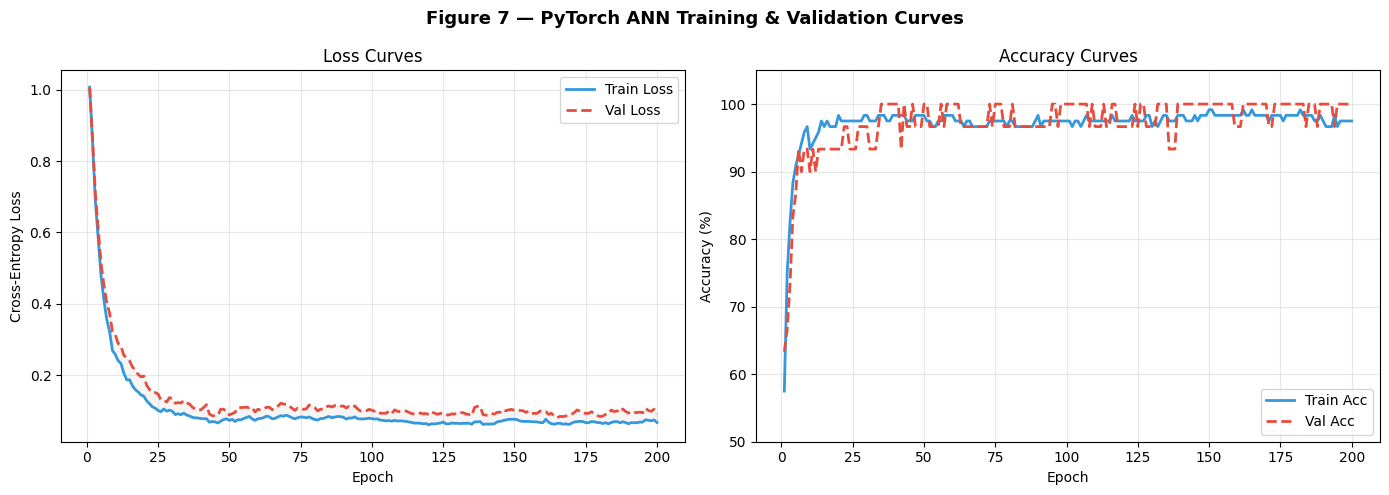


🌿 PyTorch ANN Test Accuracy: 100.00%
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
# ── Figure 7: PyTorch Training Curves with Train/Val split ──
ep = range(1, EPOCHS+1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 7 — PyTorch ANN Training & Validation Curves",
             fontsize=13, fontweight='bold')

axes[0].plot(ep, train_losses, '#3498db', lw=2, label='Train Loss')
axes[0].plot(ep, val_losses,   '#e74c3c', lw=2, label='Val Loss', ls='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Loss Curves'); axes[0].grid(True, alpha=0.3); axes[0].legend()
axes[0].fill_between(ep, train_losses, val_losses, alpha=0.08, color='gray')

axes[1].plot(ep, [a*100 for a in train_accs], '#3498db', lw=2, label='Train Acc')
axes[1].plot(ep, [a*100 for a in val_accs],   '#e74c3c', lw=2, label='Val Acc', ls='--')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy Curves'); axes[1].grid(True, alpha=0.3); axes[1].legend()
axes[1].set_ylim(50, 105)

plt.tight_layout()
plt.savefig('fig7_pytorch_training.png', dpi=150, bbox_inches='tight')
plt.show()

# Final test accuracy
model_pt.eval()
with torch.no_grad():
    y_pred_pt = model_pt(X_te_t).argmax(1).numpy()
print(f"\n🌿 PyTorch ANN Test Accuracy: {accuracy_score(y_te, y_pred_pt)*100:.2f}%")
print(classification_report(y_te, y_pred_pt, target_names=iris.target_names))


## Overfitting, Underfitting and Good Fit

<div style="text-align:center">
    <img src="https://drive.google.com/uc?export=view&id=1V1XH3C5c8cwC3QkVfeII1Q6HRjdmQZwF" width="1000"/>
    <p style="font-style:italic; color:gray; font-size:12px">Figure —
</div>

## 🔍 Section 8: Interpretability — What Did the Network Learn?

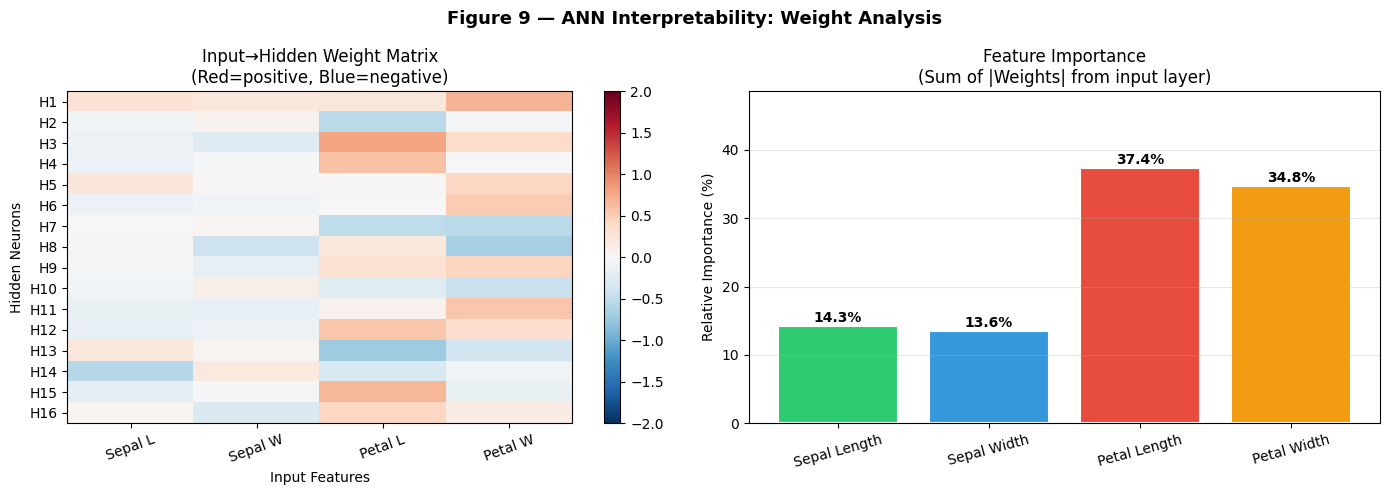

💡 Petal features dominate — consistent with botanical taxonomy!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn

# ── Extract weights from PyTorch model (no changes to SpeciesANN) ──
linear_layers = [m for m in model_pt.net if isinstance(m, nn.Linear)]
W1 = linear_layers[0].weight.detach().numpy().T  # shape (4, hidden1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 9 — ANN Interpretability: Weight Analysis",
             fontsize=13, fontweight='bold')

# Heatmap of W1
im = axes[0].imshow(W1.T, aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2)
axes[0].set_xticks(range(4))
axes[0].set_xticklabels(['Sepal L','Sepal W','Petal L','Petal W'], rotation=20)
axes[0].set_yticks(range(W1.shape[1]))
axes[0].set_yticklabels([f'H{i+1}' for i in range(W1.shape[1])])
axes[0].set_xlabel('Input Features')
axes[0].set_ylabel('Hidden Neurons')
axes[0].set_title('Input→Hidden Weight Matrix\n(Red=positive, Blue=negative)')
plt.colorbar(im, ax=axes[0])

# Feature importance: sum |W1| across hidden neurons
importance = np.abs(W1).sum(axis=1)
importance = importance / importance.sum() * 100
feat_colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
feature_names = ['Sepal Length (cm)', 'Sepal Width (cm)', 'Petal Length (cm)', 'Petal Width (cm)']
bars = axes[1].bar(feature_names, importance, color=feat_colors, edgecolor='white', lw=1.5)
axes[1].set_ylabel('Relative Importance (%)')
axes[1].set_title('Feature Importance\n(Sum of |Weights| from input layer)')
axes[1].set_ylim(0, max(importance) * 1.3)
axes[1].grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, importance):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

axes[1].set_xticklabels([f.replace(' (cm)', '') for f in feature_names], rotation=15)
plt.tight_layout()
plt.savefig('fig9_weights.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Petal features dominate — consistent with botanical taxonomy!")

- A feature with a high bar means many hidden neurons assigned it large weights — the network collectively decided this feature is important for distinguishing species.
- Red cell = large positive weight → that neuron is strongly excited by that feature
- Blue cell = large negative weight → that neuron is strongly inhibited by that feature
- White cell ≈ 0 → that neuron largely ignores that feature
- So each row tells you the "personality" of that hidden neuron — what combination of features it responds to. For example a neuron that is red on Petal L and blue on Sepal W has learned when petals are long AND sepals are narrow.

## ⚙️ Section 9: Hyperparameter Exploration

Let's investigate how **network width** affects classification performance.


Hidden=  2 | Train: 89.2% | Test: 76.7%
Hidden=  4 | Train: 92.5% | Test: 93.3%
Hidden=  8 | Train: 95.0% | Test: 93.3%
Hidden= 16 | Train: 95.8% | Test: 90.0%
Hidden= 32 | Train: 95.8% | Test: 90.0%
Hidden= 64 | Train: 96.7% | Test: 96.7%


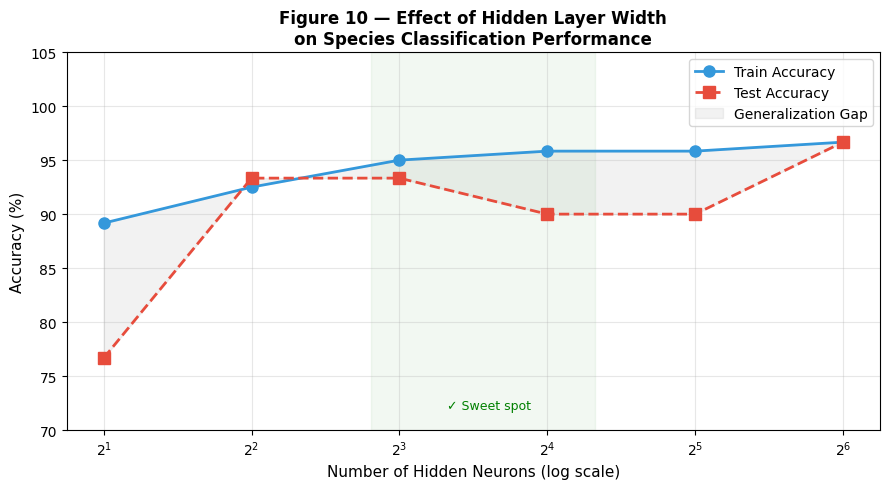

In [ ]:
# ── Figure 10: Effect of hidden layer size ──
import torch
import torch.nn as nn
import torch.optim as optim

def train_pytorch_model(hidden_size, X_tr, y_tr, X_te, y_te, epochs=300, lr=0.05):
    """Train a simple PyTorch model with given hidden size and return train/test accuracy."""

    # Convert to tensors
    X_tr_t = torch.FloatTensor(X_tr)
    y_tr_t = torch.LongTensor(y_tr)
    X_te_t = torch.FloatTensor(X_te)
    y_te_t = torch.LongTensor(y_te)

    # Simple 1-hidden-layer model for fair comparison
    model = nn.Sequential(
        nn.Linear(4, hidden_size),
        nn.ReLU(),
        nn.Linear(hidden_size, 3)
    )

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    # Train
    model.train()
    for _ in range(epochs):
        optimizer.zero_grad()
        loss = criterion(model(X_tr_t), y_tr_t)
        loss.backward()
        optimizer.step()

    # Evaluate
    model.eval()
    with torch.no_grad():
        tr_acc = (model(X_tr_t).argmax(1) == y_tr_t).float().mean().item() * 100
        te_acc = (model(X_te_t).argmax(1) == y_te_t).float().mean().item() * 100

    return tr_acc, te_acc


hidden_sizes = [2, 4, 8, 16, 32, 64]
results = []

torch.manual_seed(42)
for hs in hidden_sizes:
    torch.manual_seed(42)
    tr_acc, te_acc = train_pytorch_model(hs, X_tr, y_tr, X_te, y_te, epochs=300, lr=0.05)
    results.append({'hidden': hs, 'train_acc': tr_acc, 'test_acc': te_acc})
    print(f"Hidden={hs:3d} | Train: {tr_acc:.1f}% | Test: {te_acc:.1f}%")

res_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(res_df['hidden'], res_df['train_acc'], 'o-', color='#3498db',
        lw=2, label='Train Accuracy', ms=8)
ax.plot(res_df['hidden'], res_df['test_acc'],  's--', color='#e74c3c',
        lw=2, label='Test Accuracy', ms=8)
ax.fill_between(res_df['hidden'], res_df['train_acc'], res_df['test_acc'],
                alpha=0.1, color='gray', label='Generalization Gap')
ax.set_xscale('log', base=2)
ax.set_xlabel('Number of Hidden Neurons (log scale)', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title("Figure 10 — Effect of Hidden Layer Width\n"
             "on Species Classification Performance", fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(70, 105)
ax.axvspan(7, 20, alpha=0.05, color='green')
ax.text(10, 72, '✓ Sweet spot', color='green', fontsize=9)

plt.tight_layout()
plt.savefig('fig10_hyperparams.png', dpi=150, bbox_inches='tight')
plt.show()

## 🌍 Section 10: Real-World Biodiversity AI Applications

### From Iris to iNaturalist

The same ANN principles we just implemented power **real biodiversity tools**:

| Tool | Application | Scale |
|---|---|---|
| **iNaturalist** | Multi-species photo ID | 70,000+ species |
| **PlantNet** | Plant identification | 40,000+ plant species |
| **BirdNET** | Bird song detection | 6,000+ bird species |
| **Wildlife Insights** | Camera trap AI | Used in 90+ countries |
| **GBIF** | Global occurrence mapping | 2.5B+ observations |

### Scaling Up: From ANN to CNNs

For satellite/camera imagery, we move to **Convolutional Neural Networks (CNNs)** — but the fundamental building block (neurons, weights, backpropagation) remains identical to what we just built.

```
ANN (tabular features) → CNN (images) → Vision Transformer (foundation models)
       ↑ TODAY                                    ↑ COURSE DIRECTION
```


## Suggested readings
- https://ecyy.medium.com/what-is-artificial-neural-network-ann-7f948f90bcba
- https://www.youtube.com/watch?v=aircAruvnKk
- http://neuralnetworksanddeeplearning.com/chap1.html

## 📋 Summary & Key Takeaways

### What We Built Today:
2. ✅ ANN using **PyTorch** — production framework with BatchNorm, Dropout, Adam optimizer
3. ✅ **Decision boundary** visualization — seeing how the network separates species
4. ✅ **Feature importance** from weight analysis
5. ✅ **Hyperparameter exploration** — hidden layer width effect

### Key Concepts to Remember:
- **Neurons** = weighted sum + activation function
- **Training** = minimize loss via backpropagation + gradient descent
- **Overfitting** = gap between train and test accuracy
- **Regularization** = Dropout, BatchNorm, weight decay
- **Activation functions** = ReLU (hidden), Softmax (multi-class output)

---

